## 🔬 Retraction Risk Prediction in Scientific Publications

In this notebook, we explore whether it is possible to predict how quickly a scientific paper will be retracted using only metadata such as journal, publisher, country, and subject.

We build a machine learning pipeline on a dataset of over 64,000 retracted papers and achieve:

* **93% accuracy without using retraction reasons**
* Evidence that retraction timing is predictable *before* the cause is known

This project highlights how systemic patterns in scientific publishing can be leveraged to build early warning systems for research integrity.


# Basic Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# Update path if needed
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/global-scientific-retractions-19272026/global_scientific_retractions_1927_2026.csv")

print("Shape:", df.shape)
df.head()

Shape: (64267, 27)


,record_id,title,journal,publisher,country,author,subject,articletype,reason,retractiondate,retraction_year,retractiondoi,retractionpubmedid,originalpaperdate,original_year,originalpaperdoi,originalpaperpubmedid,years_to_retraction,institution,author_count,reason_count,subject_count,title_len,title_word_count,has_retraction_doi,has_original_doi,row_quality_flag
0,17246,The Trend-Seasonal Normal in Time Series,Journal of the American Statistical Association,Taylor and Francis,United States,C H Whelden Jr,(ENV) Climatology;,Review Article;,Error in Analyses;,4/1/1927,1927,NaN,0.0,4/1/1926,1926,NaN,0.0,0.999316,Yale University,1,1,1,40,6,0,0,OK
1,18531,Naturwissenschaft und reale Aussenwelt,Die Naturwissenschaften,Springer,Germany,Max Planck,(PHY) Physics;(SOC) Philosophy;,Review Article;,Copyright Claims;Date of Article and/or Notice...,12/1/1940,1940,10.1007/bf01488952,0.0,12/1/1940,1940,10.1007/bf01488952,0.0,0.000000,Berlin,1,2,2,38,4,1,1,OK
2,18529,Sinn und Grenzen der exakten Wissenschaft,Die Naturwissenschaften,Springer,Germany,Max Planck,(PHY) Physics;,Review Article;,Copyright Claims;Date of Article and/or Notice...,2/1/1942,1942,10.1007/bf01475382,0.0,2/1/1942,1942,10.1007/bf01475382,0.0,0.000000,Berlin,1,2,1,41,6,1,1,OK
3,10433,Change of Venue and the Conflict of Laws,The University of Chicago Law Review,University of Chicago Law School,United States,Brainerd Currie,(SOC) Law/Legal Issues;,Research Article;,Error in Results and/or Conclusions;Unreliable...,2/1/1960,1960,NaN,NaN,2/1/1955,1955,NaN,NaN,4.999316,University of Chicago;,1,2,1,40,8,0,0,OK
4,825,On the Primary Site of Nuclear RNA Synthesis,The Journal of Cell Biology,Rockefeller University Press,United States,Louise M Luckenbill;Alan S Cohen,(BLS) Biology - Cellular;(BLS) Biology - Gener...,Research Article;,Error in Results and/or Conclusions;Results No...,10/1/1966,1966,10.1083/jcb.31.1.195,5971970.0,10/1/1959,1959,10.1083/jcb.6.2.301,13850774.0,7.000684,Department of Biology University of Pennsylvan...,2,2,4,44,8,1,1,OK


# 📊 Exploratory Data Analysis

Before building models, we explore the dataset to understand patterns in retraction behavior across time, geography, publishers, and research domains.

The goal is not just visualization, but extracting meaningful insights that can inform our modeling decisions.


# check for data type and missing values

In [3]:
# basic info
print("🔹 Data Types:\n")
print(df.dtypes)

print("\n🔹 Missing Values:\n")
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df

🔹 Data Types:

record_id                  int64
title                     object
journal                   object
publisher                 object
country                   object
author                    object
subject                   object
articletype               object
reason                    object
retractiondate            object
retraction_year            int64
retractiondoi             object
retractionpubmedid       float64
originalpaperdate         object
original_year              int64
originalpaperdoi          object
originalpaperpubmedid    float64
years_to_retraction      float64
institution               object
author_count               int64
reason_count               int64
subject_count              int64
title_len                  int64
title_word_count           int64
has_retraction_doi         int64
has_original_doi           int64
row_quality_flag          object
dtype: object

🔹 Missing Values:



,missing_count,missing_percent
originalpaperdoi,5882,9.152442
originalpaperpubmedid,5065,7.881183
retractionpubmedid,5032,7.829835
retractiondoi,4546,7.073615
institution,1,0.001556
author,0,0.000000
country,0,0.000000
publisher,0,0.000000
record_id,0,0.000000
title,0,0.000000


# Target Variable 

In [4]:
threshold = df["years_to_retraction"].median()

print("Median years_to_retraction:", threshold)

df["high_risk"] = (df["years_to_retraction"] <= threshold).astype(int)

df["high_risk"].value_counts()

Median years_to_retraction: 1.311430527


high_risk
1    32149
0    32118
Name: count, dtype: int64

# Distribution of Target + Key Feature

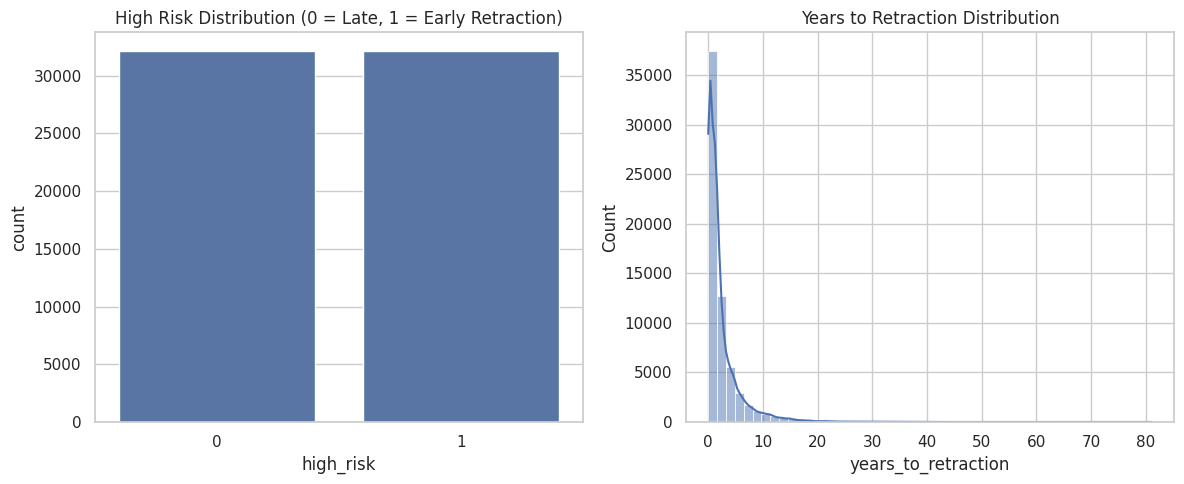

In [5]:
plt.figure(figsize=(12,5))

# Target distribution
plt.subplot(1,2,1)
sns.countplot(x="high_risk", data=df)
plt.title("High Risk Distribution (0 = Late, 1 = Early Retraction)")

# Years to retraction distribution
plt.subplot(1,2,2)
sns.histplot(df["years_to_retraction"], bins=50, kde=True)
plt.title("Years to Retraction Distribution")

plt.tight_layout()
plt.show()

Highly right-skewed distribution ⚠️
→ Most papers get retracted very quickly (0–3 years)
→ Few extreme cases go up to 80+ years (!!)
This means:
Dataset has long-tail behavior
Some extreme outliers exist → may affect models

#  Retractions Over Time

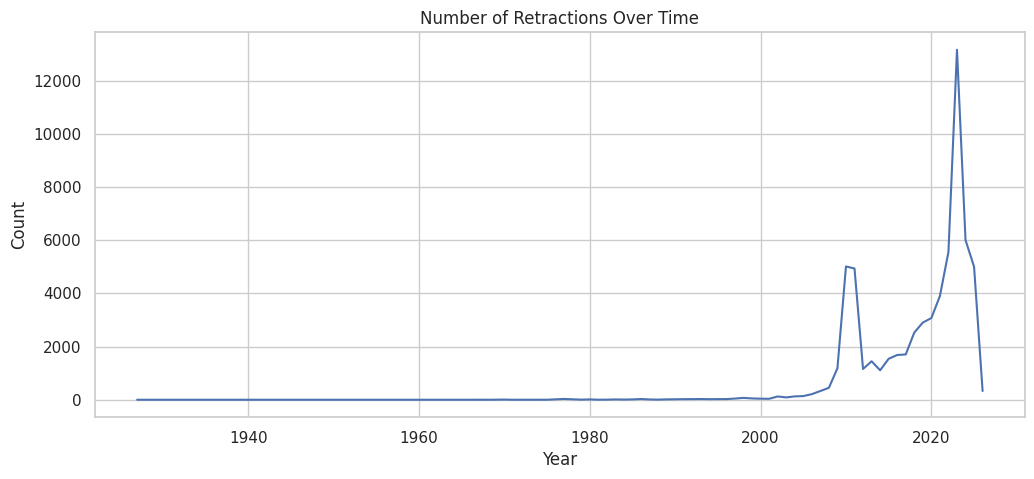

In [6]:
retractions_per_year = df.groupby("retraction_year").size()

plt.figure(figsize=(12,5))
retractions_per_year.plot()
plt.title("Number of Retractions Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Numerical Feature Risk

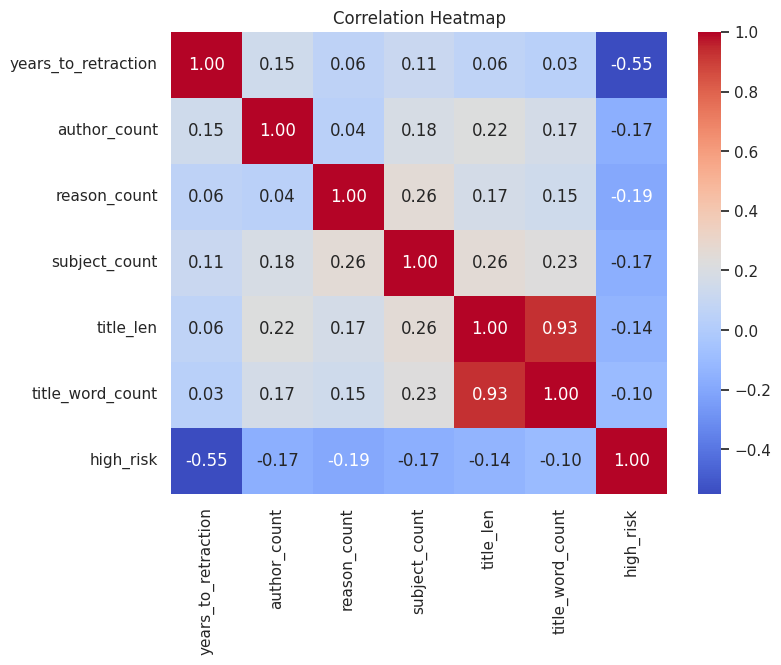

In [7]:
# correlation with target
numeric_cols = [
    "years_to_retraction",
    "author_count",
    "reason_count",
    "subject_count",
    "title_len",
    "title_word_count"
]

corr = df[numeric_cols + ["high_risk"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Categorical Feature Power

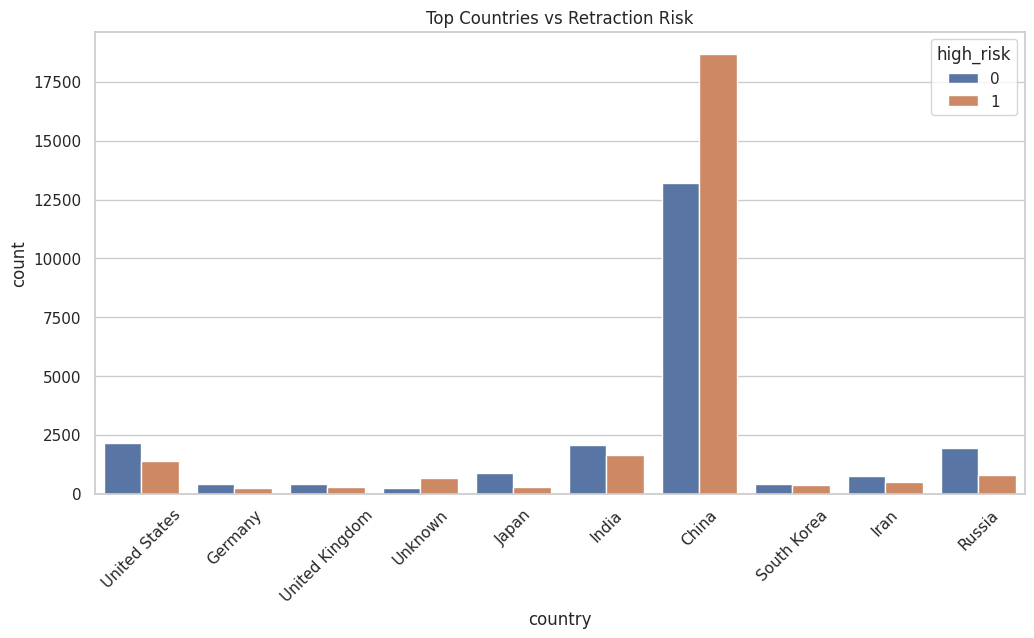

In [8]:
top_countries = df["country"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df[df["country"].isin(top_countries)], 
              x="country", hue="high_risk")

plt.xticks(rotation=45)
plt.title("Top Countries vs Retraction Risk")
plt.show()

* China → noticeably more high-risk (early retractions)
* US, India, Russia → more late retractions (low risk)
* Some countries show clear imbalance patterns

# Country vs Retraction Speed

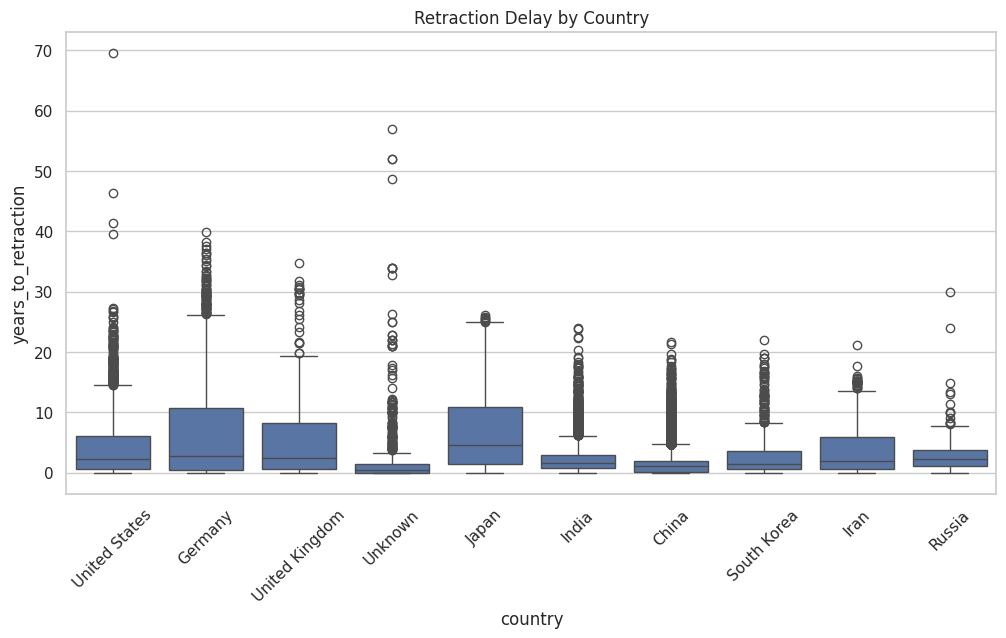

In [9]:
top_countries = df["country"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df[df["country"].isin(top_countries)],
    x="country",
    y="years_to_retraction"
)

plt.xticks(rotation=45)
plt.title("Retraction Delay by Country")
plt.show()

# Publisher Analysis

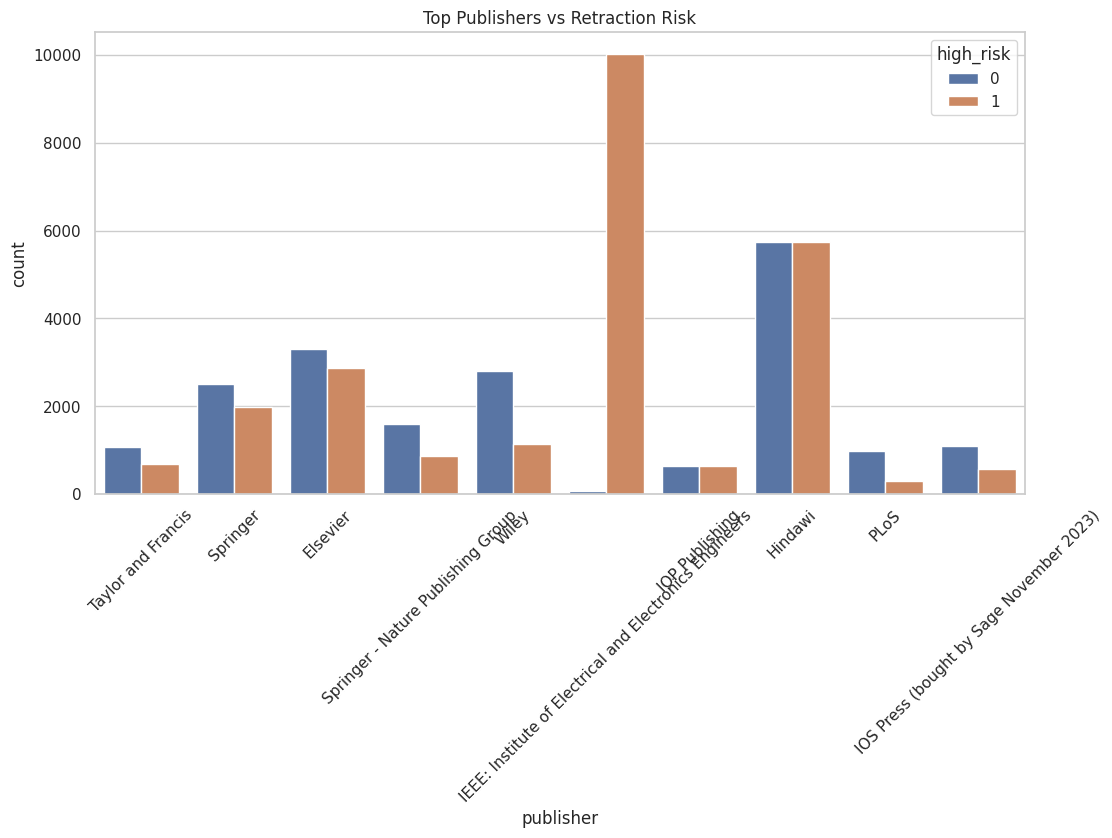

In [10]:
top_publishers = df["publisher"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df[df["publisher"].isin(top_publishers)], 
              x="publisher", hue="high_risk")

plt.xticks(rotation=45)
plt.title("Top Publishers vs Retraction Risk")
plt.show()

* Some publishers (like one extreme spike you see 👀) → almost entirely high-risk
* Others (Elsevier, Springer, Wiley) → more balanced but still skewed
* Some → clearly slower retraction systems 

# Journal Analysis

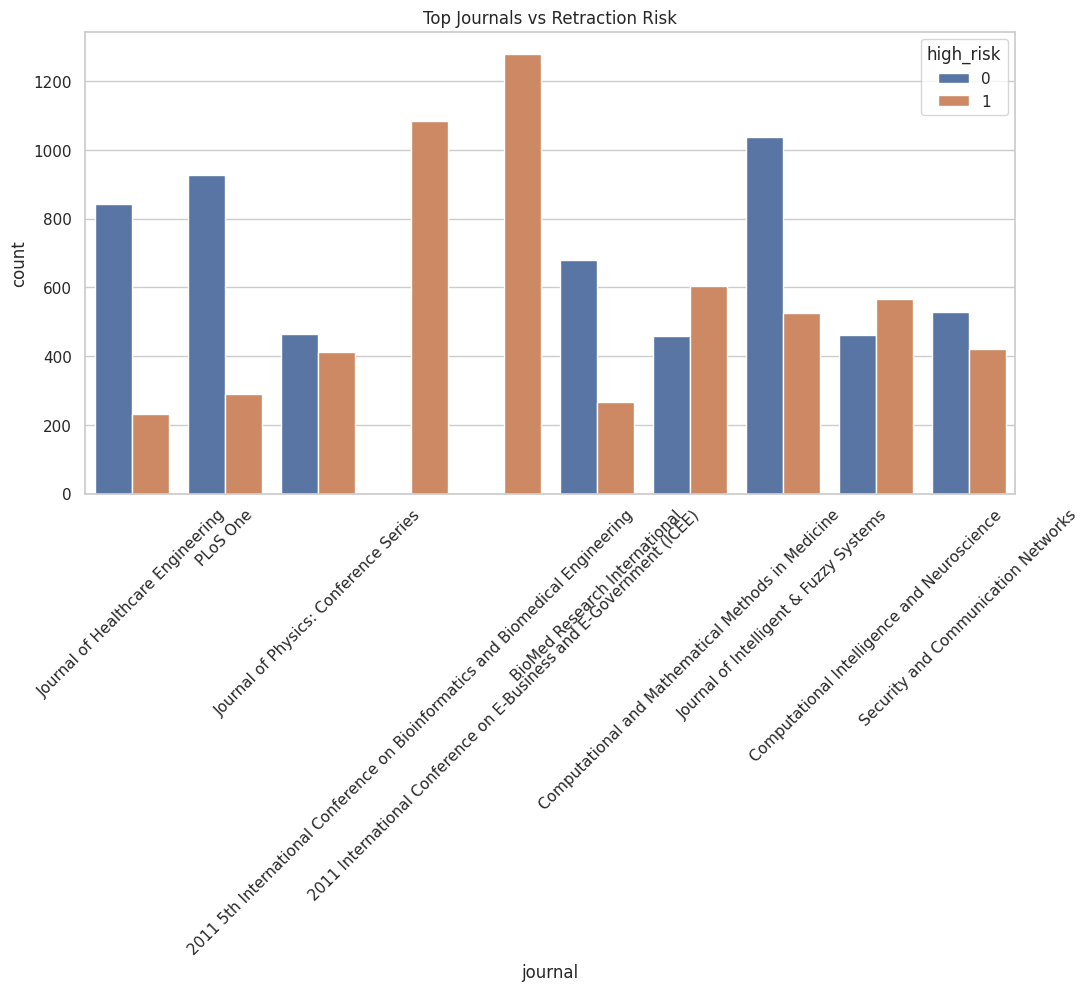

In [11]:
# Top journals vs risk
top_journals = df["journal"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df[df["journal"].isin(top_journals)], 
              x="journal", hue="high_risk")

plt.xticks(rotation=45)
plt.title("Top Journals vs Retraction Risk")
plt.show()

* Some journals are almost entirely high-risk (early retraction)
* Some are clearly low-risk (late retraction)
* Much sharper separation than publisher

👉 This confirms:
✅ journal = TOP predictive feature

# Final Feature Selection

In [12]:
# Drop leakage + redundant columns

df_model = df.copy()

df_model = df_model.drop(columns=["years_to_retraction"])

df_model = df_model.drop(columns=["title_len"])  # keeping title_word_count

df_model = df_model.drop(columns=[
    "record_id",
    "retractiondate",
    "originalpaperdate",
    "retractiondoi",
    "originalpaperdoi",
    "retractionpubmedid",
    "originalpaperpubmedid"
])

print("Remaining columns:")
print(df_model.columns)

Remaining columns:
Index(['title', 'journal', 'publisher', 'country', 'author', 'subject',
       'articletype', 'reason', 'retraction_year', 'original_year',
       'institution', 'author_count', 'reason_count', 'subject_count',
       'title_word_count', 'has_retraction_doi', 'has_original_doi',
       'row_quality_flag', 'high_risk'],
      dtype='object')


# Feature Categorization

In [13]:
# Separate feature types

target = "high_risk"

text_cols = ["title", "reason", "subject"]
high_card_cols = ["journal", "publisher", "author", "institution"]
low_card_cols = ["country", "articletype", "row_quality_flag"]

numeric_cols = [
    "retraction_year",
    "original_year",
    "author_count",
    "reason_count",
    "subject_count",
    "title_word_count",
    "has_retraction_doi",
    "has_original_doi"
]

print("Text cols:", text_cols)
print("High-cardinality cols:", high_card_cols)
print("Low-cardinality cols:", low_card_cols)
print("Numeric cols:", numeric_cols)

Text cols: ['title', 'reason', 'subject']
High-cardinality cols: ['journal', 'publisher', 'author', 'institution']
Low-cardinality cols: ['country', 'articletype', 'row_quality_flag']
Numeric cols: ['retraction_year', 'original_year', 'author_count', 'reason_count', 'subject_count', 'title_word_count', 'has_retraction_doi', 'has_original_doi']


# Fix Country Encoding

In [14]:
# First, let's inspect unique values count
print("Unique country values:", df_model["country"].nunique())

Unique country values: 3179


In [15]:
from sklearn.preprocessing import MultiLabelBinarizer

# split country string into list
df_model["country_list"] = df_model["country"].apply(lambda x: x.split(";"))

# apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()
country_encoded = mlb.fit_transform(df_model["country_list"])

# convert to dataframe
country_df = pd.DataFrame(
    country_encoded,
    columns=["country_" + c for c in mlb.classes_]
)

print("Shape:", country_df.shape)
country_df.head()

Shape: (64267, 184)


,country_Afghanistan,country_Albania,country_Algeria,country_Angola,country_Anguilla,country_Argentina,country_Armenia,country_Aruba,country_Australia,country_Austria,country_Azerbaijan,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bolivia,country_Bosnia & Herzegovina,country_Botswana,country_Brazil,country_Brunei (Brunei Darussalam),country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cayman Islands,country_Central African Republic,country_Chad,country_Chile,country_China,country_Colombia,country_Comoros,country_Cook Islands,country_Costa Rica,country_Cote d'Ivoire,country_Croatia,country_Cuba,country_Cyprus,country_Czech Republic,country_Democratic Republic of the Congo,country_Denmark,country_Dominica,country_Dominican Republic,country_East Timor,country_Ecuador,country_Egypt,country_El Salvador,country_Eritrea,country_Estonia,country_Eswatini (formerly Swaziland),country_Ethiopia,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_French Guiana,country_French Polynesia,country_Gabon,country_Gambia,country_Gaza Strip,country_Georgia,country_Germany,country_Ghana,country_Greece,country_Grenada,country_Guatemala,country_Guyana,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran,country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Kosovo,country_Kuwait,country_Kyrgyzstan,country_Laos,country_Latvia,country_Lebanon,country_Lesotho,country_Liberia,country_Libya,country_Lithuania,country_Luxembourg,country_Macau,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Mali,country_Malta,country_Mauritius,country_Mexico,country_Moldova,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar (formerly Burma),country_Namibia,country_Nepal,country_Netherlands,country_New Zealand,country_Niger,country_Nigeria,country_North Korea,country_North Macedonia (formerly Macedonia),country_Norway,country_Oman,country_Pakistan,country_Palestine,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Republic of the Congo (Congo-Brazzaville),country_Romania,country_Russia,country_Rwanda,country_Réunion Island,country_Saint Vincent & the Grenadines,country_Samoa,country_Saudi Arabia,country_Senegal,country_Serbia,country_Sierra Leone,country_Singapore,country_Sint Maarten,country_Slovakia,country_Slovenia,country_Somalia,country_South Africa,country_South Korea,country_Spain,country_Sri Lanka,country_St. Kitts & Nevis,country_Sudan,country_Sweden,country_Switzerland,country_Syria,country_Taiwan,country_Tajikistan,country_Tanzania,country_Thailand,country_Togo,country_Trinidad & Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_U,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Unknown,country_Uruguay,country_Uzbekistan,country_Venezuela,country_Vietnam,country_Yemen,country_Zambia,country_Zimbabwe
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

# Apply SAME FIX to subject

In [16]:
# split subject
df_model["subject_list"] = df_model["subject"].apply(lambda x: x.split(";"))

# encode
mlb_subject = MultiLabelBinarizer()
subject_encoded = mlb_subject.fit_transform(df_model["subject_list"])

# dataframe
subject_df = pd.DataFrame(
    subject_encoded,
    columns=["subject_" + s for s in mlb_subject.classes_]
)

print("Shape:", subject_df.shape)
subject_df.head()

Shape: (64267, 131)


,subject_,subject_(B/T) Business - Accounting,subject_(B/T) Business - Economics,subject_(B/T) Business - General,subject_(B/T) Business - Management,subject_(B/T) Business - Manufacturing,subject_(B/T) Business - Marketing,subject_(B/T) Business - Public Relations,subject_(B/T) Computer Science,subject_(B/T) Data Science,subject_(B/T) Foreign Aid,subject_(B/T) Government,subject_(B/T) International Relations,subject_(B/T) Technology,subject_(B/T) Transportation,subject_(B/T) Urban Planning,subject_(BLS) Agriculture,subject_(BLS) Anatomy/Physiology,subject_(BLS) Anthropology,subject_(BLS) Archeology,subject_(BLS) Biochemistry,subject_(BLS) Biology - Cancer,subject_(BLS) Biology - Cellular,subject_(BLS) Biology - General,subject_(BLS) Biology - Molecular,subject_(BLS) Forensic Sciences,subject_(BLS) Genetics,subject_(BLS) Microbiology,subject_(BLS) Neuroscience,subject_(BLS) Nutrition,subject_(BLS) Paleontology,subject_(BLS) Parasitology,subject_(BLS) Plant Biology/Botany,subject_(BLS) Toxicology,subject_(BLS) Zoology,subject_(ENV) Climate Change,subject_(ENV) Climatology,subject_(ENV) Ecology,subject_(ENV) Environmental Sciences,subject_(ENV) Food Science,subject_(ENV) Ground/Surface Water,subject_(HSC) Biostatistics/Epidemiology,subject_(HSC) Medicine - Alternative,subject_(HSC) Medicine - Anesthesia/Anaesthesia,subject_(HSC) Medicine - Cardiology,subject_(HSC) Medicine - Cardiovascular,subject_(HSC) Medicine - Dentistry,subject_(HSC) Medicine - Dermatology,subject_(HSC) Medicine - Diabetes,subject_(HSC) Medicine - Drug Design,subject_(HSC) Medicine - Endocrinology,subject_(HSC) Medicine - Gastroenterology,subject_(HSC) Medicine - General,subject_(HSC) Medicine - Geriatric,subject_(HSC) Medicine - Immunology,subject_(HSC) Medicine - Infectious Disease,subject_(HSC) Medicine - Internal,subject_(HSC) Medicine - Neurology,subject_(HSC) Medicine - Nursing,subject_(HSC) Medicine - Obstetrics/Gynecology,subject_(HSC) Medicine - Oncology,subject_(HSC) Medicine - Ophthalmology,subject_(HSC) Medicine - Orthopedics,subject_(HSC) Medicine - Otorhinolaryngology,subject_(HSC) Medicine - Pathology,subject_(HSC) Medicine - Pediatrics,subject_(HSC) Medicine - Pharmacology,subject_(HSC) Medicine - Psychiatry,subject_(HSC) Medicine - Pulmonology,subject_(HSC) Medicine - Rehabilitation/Therapy,subject_(HSC) Medicine - Sports,subject_(HSC) Medicine - Surgery,subject_(HSC) Medicine - Transplantation,subject_(HSC) Medicine - Urology/Nephrology,subject_(HSC) Nutrition,subject_(HSC) Occupational Health and Safety,subject_(HSC) Public Health and Safety,subject_(HSC) Radiology/Imaging,subject_(HSC) Sports Science,subject_(HSC) Veterinary Science,subject_(HUM) Architecture,subject_(HUM) Arts - Biography,subject_(HUM) Arts - Film Studies,subject_(HUM) Arts - General,subject_(HUM) Arts - Music,subject_(HUM) Arts -Literature/Poetry,subject_(HUM) Cartography,subject_(HUM) History - Africa,subject_(HUM) History - Asia,subject_(HUM) History - Australia,subject_(HUM) History - Europe,subject_(HUM) History - General,subject_(HUM) History - North America,subject_(HUM) History - South America,subject_(HUM) History - United States,subject_(HUM) Journalism,subject_(HUM) Philosophy,subject_(HUM) Religion,subject_(PHY) Astronomy,subject_(PHY) Astrophysics,subject_(PHY) Chemistry,subject_(PHY) Cosmology,subject_(PHY) Crystallography/Spectroscopy,subject_(PHY) Energy,subject_(PHY) Engineering - Chemical,subject_(PHY) Engineering - Electrical,subject_(PHY) Engineering - General,subject_(PHY) Engineering - Mechanical,subject_(PHY) Engineering - Structural,subject_(PHY) Forensic Sciences,subject_(PHY) Geology,subject_(PHY) Hydrology,subject_(PHY) Materials Science,subject_(PHY) Mathematics,subject_(PHY) Nanotechnology,subject_(PHY) Physics,subject_(PHY) Statistics,subject_(SOC) Communications,subject_(SOC) Criminology,subject_(SOC) Education,subject_(SOC) Ethics/Bioethics,subject_(SOC) Forensics,subject_(SOC) Law/Legal Issues,subject_(SOC) Linguistics,subject_(SOC) Milit

# Encode reason

In [17]:
# split reason
df_model["reason_list"] = df_model["reason"].apply(lambda x: x.split(";"))

# encode
mlb_reason = MultiLabelBinarizer()
reason_encoded = mlb_reason.fit_transform(df_model["reason_list"])

# dataframe
reason_df = pd.DataFrame(
    reason_encoded,
    columns=["reason_" + r for r in mlb_reason.classes_]
)

print("Shape:", reason_df.shape)
reason_df.head()

Shape: (64267, 111)


,reason_,reason_Author Unresponsive,reason_Bias Issues or Lack of Balance,reason_Breach of Policy by Author,reason_Cites Retracted Work,reason_Civil Proceedings,reason_Complaints about Author,reason_Complaints about Company/Institution,reason_Complaints about Third Party,reason_Compromised Peer Review,reason_Computer-Aided Content or Computer-Generated Content,reason_Concerns/Issues about Animal Welfare,reason_Concerns/Issues about Article,reason_Concerns/Issues about Authorship/Affiliation,reason_Concerns/Issues about Data,reason_Concerns/Issues about Human Subject Welfare,reason_Concerns/Issues about Image,reason_Concerns/Issues about Methods,reason_Concerns/Issues about Peer Review,reason_Concerns/Issues about Referencing/Attributions,reason_Concerns/Issues about Results and/or Conclusions,reason_Concerns/Issues about Third Party Involvement,reason_Conflict of Interest,reason_Contamination of Cell Lines/Tissues,reason_Contamination of Materials,reason_Copyright Claims,reason_Criminal Proceedings,reason_Date of Article and/or Notice Unknown,reason_Doing the Right Thing,reason_Duplication of Content through Error by Journal/Publisher,reason_Duplication of Data,reason_Duplication of Text,reason_Duplication of/in Article,reason_Duplication of/in Image,reason_Error by Journal/Publisher,reason_Error by Third Party,reason_Error in Analyses,reason_Error in Cell Lines/Tissues,reason_Error in Data,reason_Error in Image,reason_Error in Materials,reason_Error in Methods,reason_Error in Results and/or Conclusions,reason_Error in Text,reason_Ethical Violations by Author,reason_Ethical Violations by Company/Institution/Third Party,reason_Euphemisms for Duplication,reason_Euphemisms for Misconduct,reason_Euphemisms for Plagiarism,reason_False/Forged Affiliation,reason_False/Forged Authorship,reason_Falsification/Fabrication of Data,reason_Falsification/Fabrication of Image,reason_Falsification/Fabrication of Results,reason_Hoax Paper,reason_Informed/Patient Consent - None/Withdrawn,reason_Investigation by Company/Institution,reason_Investigation by Journal/Publisher,reason_Investigation by ORI,reason_Investigation by Third Party,reason_Lack of Approval from Author,reason_Lack of Approval from Company/Institution,reason_Lack of Approval from Third Party,reason_Lack of IRB/IACUC Approval and/or Compliance,reason_Legal Reasons and/or Threats,reason_Manipulation of Data,reason_Manipulation of Images,reason_Manipulation of Results,reason_Miscommunication with/by Author,reason_Miscommunication with/by Company/Institution,reason_Miscommunication with/by Journal/Publisher,reason_Miscommunication with/by Third Party,reason_Misconduct - Official Investigation(s) and/or Finding(s),reason_Misconduct by Author,reason_Misconduct by Company/Institution,reason_Misconduct by Third Party,reason_No Further Action,reason_Nonpayment of Fees and/or Refusal to Pay,reason_Not Presented at Conference,reason_Notice - Lack of,reason_Notice - Limited or No Information,reason_Notice - Unable to Access via current resources,reason_Objections by Author(s),reason_Objections by Company/Institution,reason_Objections by Third Party,reason_Original Data and/or Images not Provided and/or not Available,reason_Paper Mill,reason_Plagiarism of Data,reason_Plagiarism of Image,reason_Plagiarism of Text,reason_Plagiarism of/in Article,reason_Publishing Ban,reason_Removed,reason_Results Not Reproducible,reason_Retract and Replace,reason_Rogue Editor,reason_Sabotage of Materials/Methods,reason_Salami Slicing,reason_Taken from Dissertation/Thesis,reason_Taken via Peer Review,reason_Taken via Translation,reason_Temporary Removal,reason_Transfer of Copyright and/or Ownership,reason_Unreliable Data,reason_Unreliable Image,reason_Unreliable Results and/or Conclusions,reason_Updated to Correction,reason_Updated to Retraction,reason_Upgrade/Update of Prior Notice(s),reason_Withdrawn as Out of Date,reason_Withdrawn to Publish in Different Journal
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

# High-Cardinality Encoding

In [18]:
# frequency encoding function
def frequency_encoding(col):
    freq = df_model[col].value_counts(normalize=True)
    return df_model[col].map(freq)

# apply encoding
df_model["journal_freq"] = frequency_encoding("journal")
df_model["publisher_freq"] = frequency_encoding("publisher")

# preview
df_model[["journal", "journal_freq", "publisher", "publisher_freq"]].head()

,journal,journal_freq,publisher,publisher_freq
0,Journal of the American Statistical Association,0.000031,Taylor and Francis,0.027324
1,Die Naturwissenschaften,0.000031,Springer,0.069989
2,Die Naturwissenschaften,0.000031,Springer,0.069989
3,The University of Chicago Law Review,0.000016,University of Chicago Law School,0.000016
4,The Journal of Cell Biology,0.000187,Rockefeller University Press,0.000373


# Final Feature Assembly

In [19]:
# combine all features

final_df = pd.concat([
    df_model[numeric_cols],
    df_model[["journal_freq", "publisher_freq"]],
    country_df,
    subject_df,
    reason_df
], axis=1)

# target
y = df_model["high_risk"]

print("Final feature shape:", final_df.shape)
final_df.head()

Final feature shape: (64267, 436)


,retraction_year,original_year,author_count,reason_count,subject_count,title_word_count,has_retraction_doi,has_original_doi,journal_freq,publisher_freq,country_Afghanistan,country_Albania,country_Algeria,country_Angola,country_Anguilla,country_Argentina,country_Armenia,country_Aruba,country_Australia,country_Austria,country_Azerbaijan,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bolivia,country_Bosnia & Herzegovina,country_Botswana,country_Brazil,country_Brunei (Brunei Darussalam),country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cayman Islands,country_Central African Republic,country_Chad,country_Chile,country_China,country_Colombia,country_Comoros,country_Cook Islands,country_Costa Rica,country_Cote d'Ivoire,country_Croatia,country_Cuba,country_Cyprus,country_Czech Republic,country_Democratic Republic of the Congo,country_Denmark,country_Dominica,country_Dominican Republic,country_East Timor,country_Ecuador,country_Egypt,country_El Salvador,country_Eritrea,country_Estonia,country_Eswatini (formerly Swaziland),country_Ethiopia,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_French Guiana,country_French Polynesia,country_Gabon,country_Gambia,country_Gaza Strip,country_Georgia,country_Germany,country_Ghana,country_Greece,country_Grenada,country_Guatemala,country_Guyana,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran,country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Kosovo,country_Kuwait,country_Kyrgyzstan,country_Laos,country_Latvia,country_Lebanon,country_Lesotho,country_Liberia,country_Libya,country_Lithuania,country_Luxembourg,country_Macau,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Mali,country_Malta,country_Mauritius,country_Mexico,country_Moldova,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar (formerly Burma),country_Namibia,country_Nepal,country_Netherlands,country_New Zealand,country_Niger,country_Nigeria,country_North Korea,country_North Macedonia (formerly Macedonia),country_Norway,country_Oman,country_Pakistan,country_Palestine,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Republic of the Congo (Congo-Brazzaville),country_Romania,country_Russia,country_Rwanda,country_Réunion Island,country_Saint Vincent & the Grenadines,country_Samoa,country_Saudi Arabia,country_Senegal,country_Serbia,country_Sierra Leone,country_Singapore,country_Sint Maarten,country_Slovakia,country_Slovenia,country_Somalia,country_South Africa,country_South Korea,country_Spain,country_Sri Lanka,country_St. Kitts & Nevis,country_Sudan,country_Sweden,country_Switzerland,country_Syria,country_Taiwan,country_Tajikistan,country_Tanzania,country_Thailand,country_Togo,country_Trinidad & Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_U,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Unknown,country_Uruguay,country_Uzbekistan,country_Venezuela,country_Vietnam,country_Yemen,country_Zambia,country_Zimbabwe,subject_,subject_(B/T) Business - Accounting,subject_(B/T) Business - Economics,subject_(B/T) Business - General,subject_(B/T) Business - Management,subject_(B/T) Business - Manufacturing,subject_(B/T) Business - Marketing,subject_(B/T) Business - Public Relations,subject_(B/T) Computer Science,subject_(B/T) Data Science,subject_(B/T) Foreign Aid,subject_(B/T) Government,subject_(B/T) International Relations,subject_(B/T) Technology,subject_(B/T) Transportation,subject_(B/T) Urban Planning,subject_(BLS) Agriculture,subject_(BLS) Anatomy/Phys

# Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    final_df, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (51413, 436)
Test shape: (12854, 436)


# First Model RFC (Baseline)

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# train
rf.fit(X_train, y_train)

# predict
y_pred = rf.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8166329547222655

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83      6424
           1       0.88      0.73      0.80      6430

    accuracy                           0.82     12854
   macro avg       0.83      0.82      0.82     12854
weighted avg       0.83      0.82      0.82     12854



# Feature Importance

In [22]:
import pandas as pd

# get feature importance
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": final_df.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# top features
feature_importance_df.head(20)

,feature,importance
405,reason_Notice - Limited or No Information,0.122463
9,publisher_freq,0.101779
0,retraction_year,0.093824
1,original_year,0.091118
3,reason_count,0.058870
358,reason_Duplication of/in Image,0.036375
328,reason_Breach of Policy by Author,0.034647
352,reason_Date of Article and/or Notice Unknown,0.031102
8,journal_freq,0.026630
430,reason_Unreliable Results and/or Conclusions,0.025814


# Upgrade Model (XGBoost 🔥)

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# train
xgb.fit(X_train, y_train)

# predict
y_pred_xgb = xgb.predict(X_test)

# evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9394740936673409

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      6424
           1       0.92      0.96      0.94      6430

    accuracy                           0.94     12854
   macro avg       0.94      0.94      0.94     12854
weighted avg       0.94      0.94      0.94     12854



# Real-World Model (NO REASON)

In [24]:
# remove reason features
no_reason_cols = [col for col in final_df.columns if not col.startswith("reason_")]

X_no_reason = final_df[no_reason_cols]

# split again
X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(
    X_no_reason, y, test_size=0.2, random_state=42, stratify=y
)

# train XGBoost
xgb_nr = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_nr.fit(X_train_nr, y_train_nr)

# predict
y_pred_nr = xgb_nr.predict(X_test_nr)

# evaluate
print("Accuracy (No Reason):", accuracy_score(y_test_nr, y_pred_nr))
print("\nClassification Report:\n")
print(classification_report(y_test_nr, y_pred_nr))

Accuracy (No Reason): 0.9308386494476427

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6424
           1       0.90      0.96      0.93      6430

    accuracy                           0.93     12854
   macro avg       0.93      0.93      0.93     12854
weighted avg       0.93      0.93      0.93     12854



# Feature Importance Visualization

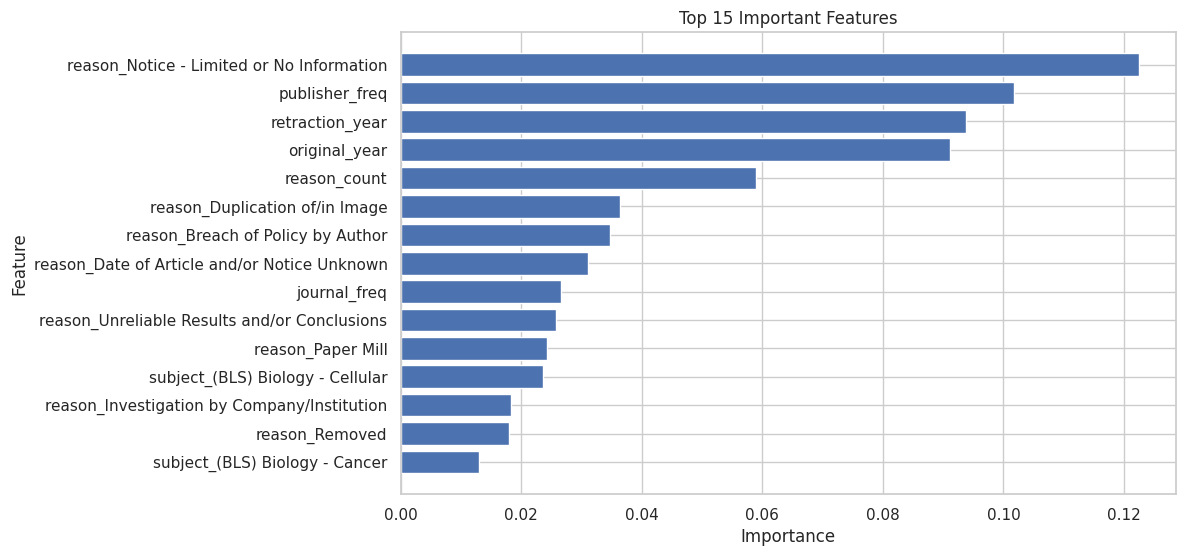

In [25]:
# Feature Importance Plot
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### 🔍 Key Observations from Feature Importance

The feature importance analysis reveals several important patterns:

* **Retraction-related signals dominate**:
  Features such as *"Notice - Limited or No Information"* and duplication-related reasons have the highest importance, indicating strong associations with faster retraction timelines.

* **Publisher and journal effects are significant**:
  The high importance of `publisher_freq` and `journal_freq` suggests that institutional and editorial practices play a major role in how quickly issues are identified and acted upon.

* **Temporal features are highly influential**:
  Both `retraction_year` and `original_year` appear among the top features, highlighting how retraction behavior has evolved over time.

* **Complexity of issues matters**:
  `reason_count` being important suggests that papers with multiple issues tend to follow different retraction timelines.

* **Domain-specific patterns exist**:
  Subjects related to biology (e.g., cellular and cancer research) appear among top features, indicating variation in retraction behavior across disciplines.

Overall, these results confirm that retraction timing is shaped by a combination of **institutional, temporal, and domain-specific factors**, rather than being purely random.


⚠️ Note on Interpretation

While retraction-related features provide strong predictive power, they may not always be available prior to investigation.

To ensure real-world applicability, we also evaluate a model that excludes all reason-related features. Interestingly, the performance remains high, reinforcing the idea that early signals exist in publication metadata itself.

💡 Micro Insight

The dominance of specific retraction reasons suggests that certain types of issues (e.g., duplication, unreliable results, or lack of transparency) are detected more quickly than others.

This could reflect:

Automated detection systems (e.g., plagiarism/image tools)
Clearer violation patterns
Faster institutional response

This highlights how type of misconduct influences detection speed.

# confusion Matrix

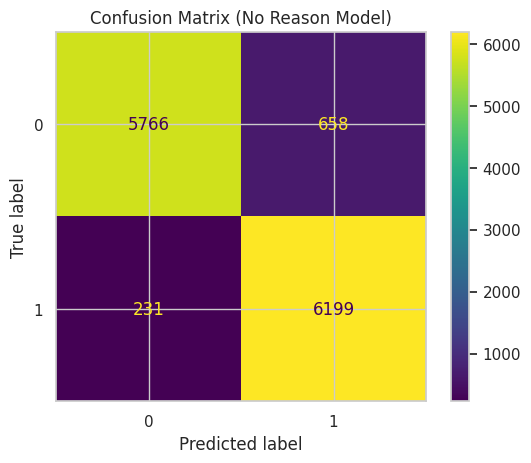

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_nr, y_pred_nr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (No Reason Model)")
plt.show()

## ⚠️ Important Consideration: Data Leakage

Using retraction reasons significantly boosts model performance. However, this introduces a potential data leakage issue, as these reasons are typically known only after investigation.

To address this, we trained a second model excluding all reason-related features.

Remarkably, the model still achieved approximately **93% accuracy**, demonstrating that retraction timing can be predicted using only metadata available prior to investigation.

This makes the model far more relevant for real-world applications.


In [27]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "XGBoost (No Reason)"],
    "Features Used": ["All", "All", "No Reason"],
    "Accuracy": [0.8166, 0.9394, 0.9308]
})

comparison_df

,Model,Features Used,Accuracy
0,Random Forest,All,0.8166
1,XGBoost,All,0.9394
2,XGBoost (No Reason),No Reason,0.9308


## 🌍 Real-World Implications

The ability to predict retraction timing using metadata alone opens up several possibilities:

* Early warning systems for high-risk publications
* Monitoring tools for publishers and journals
* Research integrity dashboards for institutions
* Prioritization of investigations based on predicted risk

Such systems could significantly improve the efficiency and transparency of scientific publishing.


## 🏁 Conclusion

This study demonstrates that retraction timing is highly predictable and influenced by identifiable patterns across journals, publishers, and research domains.

Even without access to retraction reasons, the model achieves strong performance, suggesting that early indicators of risk are embedded within publication metadata.

Future work can extend this approach by incorporating textual analysis and real-time monitoring systems to further enhance predictive capabilities.
